#  Setup

# Install SHAP missing, then load XGBoost (our core model).
# SHAP explains WHY each transaction was flagged — critical for
# fraud analyst review and for regulatory compliance.


In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

xgb = joblib.load("../models/xgboost.pkl")
print("XGBoost loaded.")
print("Test set:", X_test.shape)

e:\sentinelfraud\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost loaded.
Test set: (56746, 30)


#  Build SHAP Explainer

# TreeExplainer is the fast, exact SHAP method for tree models
# like XGBoost that why i use this method. It computes Shapley values per feature per
# prediction in milliseconds — fast enough for real-time API use.

In [2]:
explainer = shap.TreeExplainer(xgb)

# Compute SHAP values on a sample (full test set is slow)
sample_idx = np.random.RandomState(42).choice(len(X_test), size=2000, replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample)
print("SHAP values computed:", shap_values.shape)

SHAP values computed: (2000, 30)


#  Global Feature Importance (Summary Plot)

# Summary plot shows which features drive fraud overall, and
# in which direction. Features at the top matter most. Red =
# high feature value pushes toward fraud; blue = pushes away.
# This is your headline "what causes fraud" visualization.


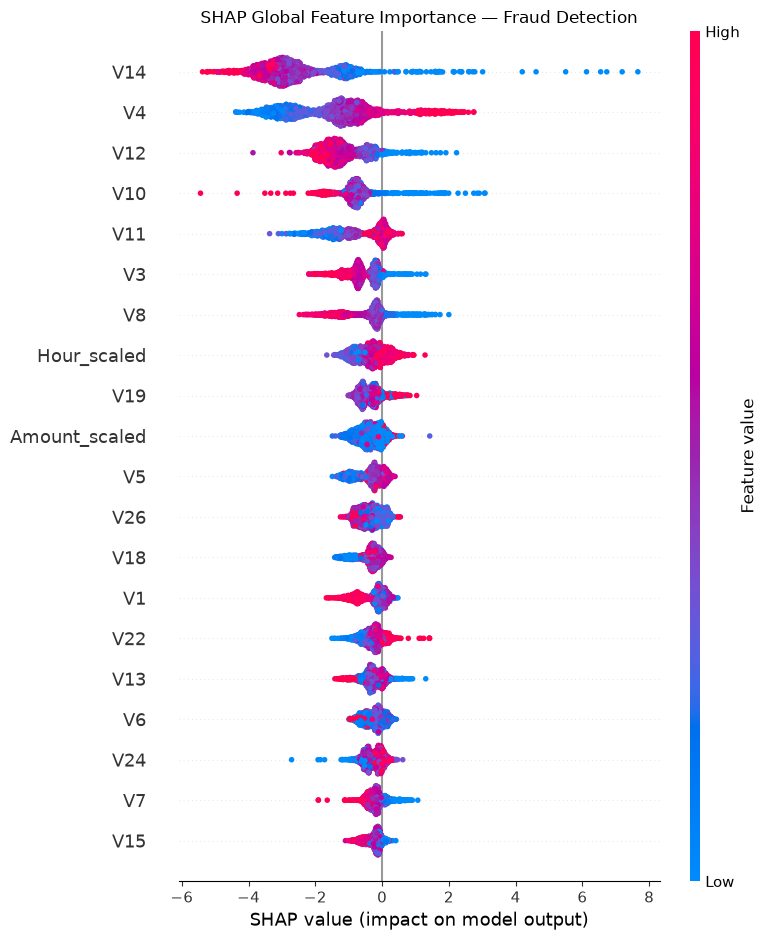

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Global Feature Importance — Fraud Detection")
plt.tight_layout()
plt.savefig("../models/shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

# Bar Plot (Mean Absolute SHAP)

# Simpler version of Cell 3. Ranks features by average impact
# magnitude. Goes straight into the README and the FastAPI
# /feature-importance endpoint.


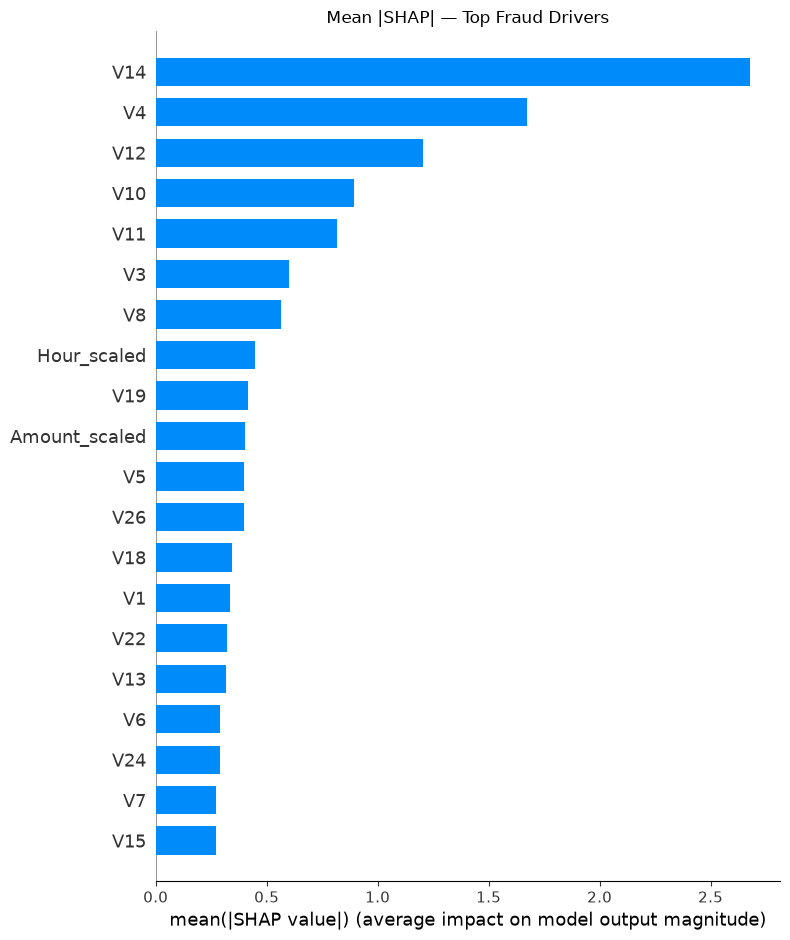


Top 10 fraud drivers:
      feature  importance
          V14    2.678652
           V4    1.672479
          V12    1.205370
          V10    0.893699
          V11    0.815939
           V3    0.600657
           V8    0.562535
  Hour_scaled    0.448922
          V19    0.416233
Amount_scaled    0.400672


In [5]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Mean |SHAP| — Top Fraud Drivers")
plt.tight_layout()
plt.savefig("../models/shap_bar.png", dpi=120, bbox_inches="tight")
plt.show()

# Save top 10 features to JSON for API use
mean_abs = np.abs(shap_values).mean(axis=0)
top_features = pd.DataFrame({
    "feature": X_sample.columns,
    "importance": mean_abs
}).sort_values("importance", ascending=False).head(10)

print("\nTop 10 fraud drivers:")
print(top_features.to_string(index=False))

top_features.to_csv("../models/top_features.csv", index=False)

#  Explaining a SINGLE Fraud Prediction


# This is what a fraud analyst sees. Pick one actual fraud from
# the test set, show the SHAP waterfall — which features pushed
# it toward fraud, which pulled it away. This is the money
# feature for your API's /explain endpoint.


Explaining transaction #1195 | True label: FRAUD
Model probability: 1.0000


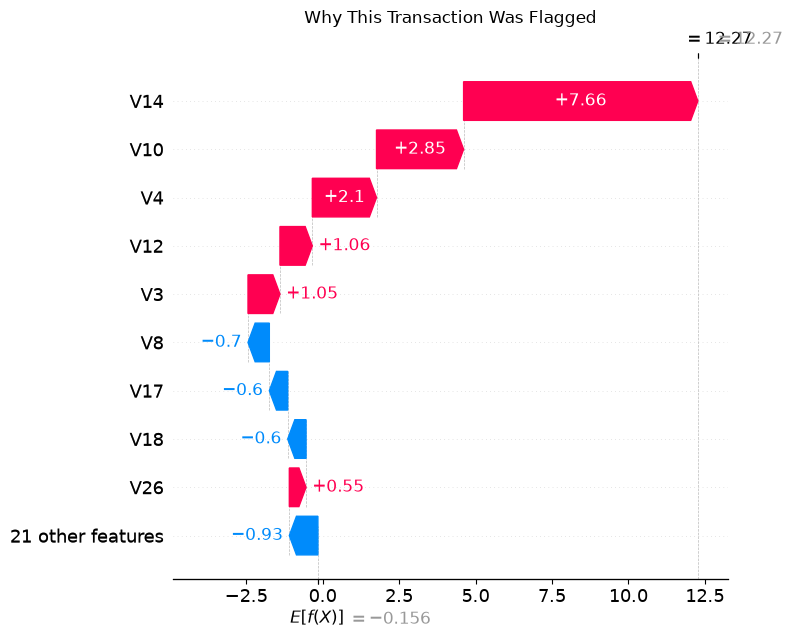

In [6]:
# Finding a fraud the model caught with high confidence
fraud_idx = np.where(y_sample.values == 1)[0]
if len(fraud_idx) == 0:
    print("No fraud in sample — increase sample size")
else:
    # Picking the fraud with highest predicted probability
    probs = xgb.predict_proba(X_sample.iloc[fraud_idx])[:, 1]
    best_fraud = fraud_idx[np.argmax(probs)]
    print(f"Explaining transaction #{best_fraud} | True label: FRAUD")
    print(f"Model probability: {probs.max():.4f}")

    plt.figure()
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values[best_fraud],
        feature_names=X_sample.columns.tolist(),
        show=False
    )
    plt.title("Why This Transaction Was Flagged")
    plt.tight_layout()
    plt.savefig("../models/shap_waterfall_fraud.png", dpi=120, bbox_inches="tight")
    plt.show()

# Generating Human-Readable Explanations

# Convert SHAP values into plain English. This is the function
# the FastAPI layer will call to return explanations like:
# "Flagged because V14 is extremely low, Amount is unusually high."
# Fraud analysts don't read SHAP plots — they read sentences.


In [ ]:
def explain_transaction(shap_row, feature_row, top_n=5):
    """Return human-readable reasons for a prediction."""
    contributions = pd.DataFrame({
        "feature": feature_row.index,
        "value": feature_row.values,
        "shap": shap_row
    })
    contributions["abs_shap"] = contributions["shap"].abs()
    top = contributions.sort_values("abs_shap", ascending=False).head(top_n)

    reasons = []
    for _, r in top.iterrows():
        direction = "increased" if r["shap"] > 0 else "decreased"
        reasons.append(
            f"{r['feature']} = {r['value']:.3f} {direction} fraud risk "
            f"(SHAP: {r['shap']:+.3f})"
        )
    return reasons

# showing Demo
if len(fraud_idx) > 0:
    print("Explanation for flagged transaction:")
    for i, reason in enumerate(explain_transaction(
        shap_values[best_fraud], X_sample.iloc[best_fraud]
    ), 1):
        print(f"  {i}. {reason}")

Explanation for flagged transaction:
  1. V14 = -9.058 increased fraud risk (SHAP: +7.661)
  2. V10 = -3.944 increased fraud risk (SHAP: +2.848)
  3. V4 = 7.380 increased fraud risk (SHAP: +2.099)
  4. V12 = -7.310 increased fraud risk (SHAP: +1.058)
  5. V3 = -7.424 increased fraud risk (SHAP: +1.045)


# saveing Explainer for API

# Save the SHAP explainer + expected value so the FastAPI
# /explain endpoint can serve live explanations without
# retraining. The API will compute SHAP on-the-fly per request.


In [8]:
joblib.dump(explainer, "../models/shap_explainer.pkl")

with open("../models/shap_meta.json", "w") as f:
    json.dump({
        "expected_value": float(explainer.expected_value),
        "feature_names": X_sample.columns.tolist(),
        "top_features": top_features["feature"].tolist()
    }, f, indent=2)

print("Saved:")
print("  - models/shap_explainer.pkl")
print("  - models/shap_meta.json")
print("  - models/shap_summary.png")
print("  - models/shap_bar.png")
print("  - models/shap_waterfall_fraud.png")
print("  - models/top_features.csv")

Saved:
  - models/shap_explainer.pkl
  - models/shap_meta.json
  - models/shap_summary.png
  - models/shap_bar.png
  - models/shap_waterfall_fraud.png
  - models/top_features.csv


# Explainability Summary

**Tool:** SHAP (TreeExplainer) — exact Shapley values for XGBoost.
**Why:** Regulators and fraud analysts require per-decision reasoning.
       "Black box" models cannot be deployed in regulated finance.

**What we produced:**
1. **Global importance** (summary + bar plot) — which features drive fraud.
2. **Local explanation** (waterfall) — why THIS transaction was flagged.
3. **Plain-English reasons** — a function that converts SHAP values into
   human sentences like "V14 = -12.3 increased fraud risk (SHAP: +1.85)."

**Business impact:**
- Fraud analysts review flagged alerts faster with clear reasons.
- Auditors can trace every automated decision back to features.
- Enables "human-in-the-loop" — high-confidence flags auto-block,
  low-confidence flags go to analyst with explanation attached.

**Saved artifacts:**
- `models/shap_explainer.pkl`
- `models/shap_meta.json`
- `models/shap_summary.png`
- `models/shap_bar.png`
- `models/shap_waterfall_fraud.png`
- `models/top_features.csv`

**Next:** `src/` modules — refactor notebooks into reusable Python
modules (data_loader, features, train_supervised, etc.) so the FastAPI
layer can import them.